# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):

    Кузняков Дмитрий

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from bs4.builder import HTML

from IPython.display import display
from seaborn import pairplot
from statsmodels.tools.eval_measures import mse

In [54]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [55]:
RANDOM_STATE = 42

In [56]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

SEED необходимо фиксировать для того, что бы ноутбук обладал свойством воспроизводимости (идемпотентности как будто бы более чем подходит здесь, не понимаю почему используют термин только для API), в случае если seed не сохраняется генерация "случайных" айтемов, происходит путем использования текущего системного времени. В случае если мы используем seed для генерации то результат будет воспроизводим, за счет того что генератор всегда выдаст одинаковую последовательность.

## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [57]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [x] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [x] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [x] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [x] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [58]:
import sys

def block_title(text):
    print('\n')
    print(25 * "-")
    print(text.upper())
    print(25 * "-")
    sys.stdout.flush()

In [59]:
pre_empty_columns = df_train.isnull().sum()
empty_columns = pre_empty_columns[pre_empty_columns > 0]
df_duplicates = df_train.duplicated().sum()

block_title("Дубликаты")
print(f'Дубликатов в тренировочном датасете: {df_duplicates}')
block_title('Пропуски столбцов')
print(empty_columns)

mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64


In [60]:
from ydata_profiling import ProfileReport
block_title("Дашборд в одну строку")
profile = ProfileReport(df_train)
profile.to_notebook_iframe()

## Выводы

- Датасет содержит ~7% дубликатов, которые необходимо удалить перед обучением
- Признак `seller_type` имеет очень несбалансированные классы и является первым кандидатом на удаление
- Наибольшая корреляция наблюдается между ценой (`selling_price`) и типом трансмиссии (`transmission`)
- Всего 13 уникальных переменных, из 7000 наблюдений имеем пропуски в 1005 ячейках, что является значительной долей и требует обработки

### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [61]:
block_title("Числовые статистики - train")
print(df_train.describe(include='number'))

block_title("Числовые статистики - test")
print(df_test.describe(include='number'))

block_title("Категориальная статистика - train")
print(df_train.describe(include='object'))

block_title("Категориальная статистика - test")
print(df_test.describe(include='object'))

block_title("Сравнение среднего и медианы")
df_columns_numeric = df_train.select_dtypes(include='number').columns
df_mean_med_comparison = pd.DataFrame({
    'train_mean': df_train[df_columns_numeric].mean(),
    'test_mean': df_test[df_columns_numeric].mean(),
    'train_median': df_train[df_columns_numeric].median(),
    'test_median': df_test[df_columns_numeric].median(),
})

df_mean_med_comparison['train_diff'] = ((df_mean_med_comparison['train_mean'] - df_mean_med_comparison['train_median']) / df_mean_med_comparison['train_median'] * 100).round(2)
df_mean_med_comparison['test_diff'] = ((df_mean_med_comparison['test_mean'] - df_mean_med_comparison['test_median']) / df_mean_med_comparison['test_median'] * 100).round(2)

print(df_mean_med_comparison)

                  train_mean      test_mean  train_median  test_median  \
year             2013.818403    2013.681000        2015.0       2014.0   
selling_price  639515.197171  617901.042000      450000.0     434999.0   
km_driven       69584.615517   71393.341000       60000.0      61500.0   
seats               5.419008       5.410805           5.0          5.0   

               train_diff  test_diff  
year                -0.06      -0.02  
selling_price       42.11      42.05  
km_driven           15.97      16.09  
seats                8.38       8.22  


## Выводы

1. Мы видим, что цена очень сильно отличается медианы и среднего (на 42%), что нам говорит о том, что есть выбросы которые сильно меняют распределение.
2. km_driven - имеет скошенность (16%), и есть авто у которых очень большой пробег.
3. Year - не имеет такой сильной скошенности.
4. Seats - есть некоторый набор автомобилей в которых мест больше чем обычно.
5. Наши выборки Трейн и Тест отличается в меньше чем 2.5% что говорит, о том что выборки однообразны.


### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [62]:
# Определяем дубликаты для всех столбцов кроме таргета
features = df_train.columns.drop('selling_price')
duplicates_mask = df_train.duplicated(subset=features, keep=False)
duplicates = df_train[duplicates_mask]

block_title("Дубликаты по признакам")
print(f"Объектов с одинаковым признаковым описанием: {duplicates.shape[0]}")
print(f"Уникальных групп дубликатов: {df_train.duplicated(subset=features, keep='first').sum()}")
print('\n')
print(duplicates.sort_values(by=list(features)).head(20))
# Оставляем только первую строку
df_train = df_train.drop_duplicates(subset=features, keep='first')

# Востанавливаем индекс после удаления
df_train = df_train.reset_index(drop=True)

print(f'Size after dropping duplicates: {df_train.shape}')

Объектов с одинаковым признаковым описанием: 1799
Уникальных групп дубликатов: 1159


                                      name  year  selling_price  km_driven  \
1703  Audi Q3 2.0 TDI Quattro Premium Plus  2017        2825000      22000   
6307  Audi Q3 2.0 TDI Quattro Premium Plus  2017        2825000      22000   
1836               Audi Q5 3.0 TDI Quattro  2014        1850000      76131   
6704               Audi Q5 3.0 TDI Quattro  2014        1850000      76131   
117             Audi Q5 35TDI Premium Plus  2018        3975000      31800   
1337            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
1595            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
2787            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
4485            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
6640            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
1779         BMW 3 Series 320d Luxury Line  2012        

In [63]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [64]:
# игнорируем плохой регистр из Sales
import re

# Берем регулярку которой отрезаем все после числа
def extractor(series):
    return pd.to_numeric(series.str.extract(r'([\d.]+)')[0], errors='coerce')

for col in ['mileage', 'engine', 'max_power']:
    df_train[col] = extractor(df_train[col])
    df_test[col] = extractor(df_test[col])

# Обработка torque: разделяем на torque (Nm) и max_torque_rpm
def clean_torque(df):
    is_kgm = df['torque'].astype(str).str.contains('kgm', case=False, na=False)
    # Чисти первое число
    torque = pd.to_numeric(df['torque'].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')
    # Конвертируем kgm в Nm
    torque[is_kgm] *= 9.8066
    
    # Последнее число после @/at
    cleaned = df['torque'].astype(str).str.replace(',', '', regex=False)
    rpm = pd.to_numeric(cleaned.str.extract(r'(\d+)\s*(?:rpm)', flags=re.IGNORECASE)[0], errors='coerce')
    
    df['torque'] = torque
    df['max_torque_rpm'] = rpm

clean_torque(df_train)
clean_torque(df_test)

print(df_train[['torque', 'max_torque_rpm']].head(10))
print(f"\nTrain shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

      torque  max_torque_rpm
0  190.00000          2000.0
1  250.00000          2500.0
2  219.66784          2750.0
3  112.77590             NaN
4  113.75000          4000.0
5   76.49148             NaN
6   59.00000          2500.0
7  170.00000          2400.0
8  160.00000          2000.0
9  248.00000          2250.0

Train shape: (5840, 14)
Test shape: (1000, 14)


### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [x] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [x] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [x] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [65]:
df_train_medians = df_train.median(numeric_only=True)
df_test_medians = df_test.median(numeric_only=True)

df_train = df_train.fillna(df_train_medians)
df_test = df_test.fillna(df_train_medians)

block_title("Тест на пропуски")
print("Train NaN: ", df_train_medians.isnull().sum().sum())
print("Test NaN: ", df_test_medians.isnull().sum().sum())

Train NaN:  0
Test NaN:  0


Нужно считать по train медиану потому, что мы не всегда сможем заранее знать какая будет медиана у нового батча, а также новый батч всегда будет иметь уникальную медиану.

Это может стать даталиком, проблемой при воспроизведении и отладке, привести к несогласованным результатам обобщающих выводов модели.
Проблема батча без данных - при применении модели на новых данных может прийти маленький батч в котором посчитать медиану не возможно или же прийти большой батч в котором данных по определенному столбцу будет слишком мало, что будет сильно влиять на весь батч и в таком случае батч в котором все данные являются выбросом, а остальные данные не заполнены может стать причиной того, что наша модель будет не то, что плохо предсказывать ответ, а предсказывать вообще не верно

### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [x] Осуществите приведение столбцов к необходимому типу.
- [x] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [66]:
# Проверяем наборы
df_train['seats'].unique()
df_train['engine'].unique()

# Для перевода в категориальный признак идея была реализовывать в рамках деления по страховке и налогам, но такого нет, поэтому используем условные - " https://claude.ai/share/b2bacab9-cfc1-4850-8ff3-2c6b39a7a5c7 " чат в котором пытался найти категории.

# Добавляем перевод к нужному классу для двигателей
# Создаем обозначение наших классов
def categorical_engine(cc):
    if cc < 1500: return "subcompact"
    elif cc <= 2000: return "compact"
    elif cc <= 3000: return "midsize"
    elif cc <= 4000: return "large"
    elif cc <= 6000: return "performance_or_truck"
    else: return "heavy_duty_or_exotic"

# Переводим классы в нужные категории
def categorical_engine_int(cc):
    if cc < 1500: return "0"
    elif cc <= 2000: return "1"
    elif cc <= 3000: return "2"
    elif cc <= 4000: return "3"
    elif cc <= 6000: return "4"
    else: return "5"

df_test["engine_class"] = df_test["engine"].apply(categorical_engine)
df_test["engine_class_num"] = df_test["engine"].apply(categorical_engine_int).astype(int)

df_train["engine_class"] = df_train["engine"].apply(categorical_engine)
df_train["engine_class_num"] = df_train["engine"].apply(categorical_engine_int).astype(int)


def seats_categorical(seats):
    if seats < 2: return "small"
    elif seats < 6: return "average"
    elif seats < 9: return "mini_bus"
    elif seats < 12: return "bus"
    else: return "large"

def seats_categorical_num(seats):
    if seats < 2: return "0"
    elif seats < 6: return "1"
    elif seats < 9: return "2"
    elif seats < 12: return "3"
    else: return "4"

df_test["seats_class"] = df_test["seats"].apply(seats_categorical)
df_test["seats_class_num"] = df_test["seats"].apply(seats_categorical_num).astype(int)

df_train["seats_class"] = df_train["seats"].apply(seats_categorical)
df_train["seats_class_num"] = df_train["seats"].apply(seats_categorical_num).astype(int)

# Выполняем само задание
df_train['seats'] = df_train['seats'].astype(int)
df_train['engine'] = df_train['engine'].astype(int)

df_test['seats'] = df_test['seats'].astype(int)
df_test['engine'] = df_test['engine'].astype(int)


Мы хотим использовать категориальную переменную потому, что в данном формате нас волнует примерный диапазон и в рамках оценки таргета нас не волнует какой объем двигателя 2496 или 2497 это упрощает и обучение и влияет на качество в положительную сторону, также и с seats это скорее нам демонстрирует тип или класс автомобиля, скорее всего 2-ух местные это спорт кары а 7 и более это семейные внедорожники.

Нам бы имело смысл оставлять такую переменную не категориальной только если бы это был таргет и например мы бы хотели вычислять какой делать объем двигателя для максимизации стоимость для продажи.

P.S. в задании не было про engine, но я почему-то вдохновился и понял, что спрашивают в задании уже после того как дошел до этого места.

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [67]:
print(df_train.describe())
print(df_test.describe())

              year  selling_price     km_driven      mileage       engine  \
count  5840.000000   5.840000e+03  5.840000e+03  5840.000000  5840.000000   
mean   2013.428425   5.229601e+05  7.395224e+04    19.430841  1429.448973   
std       4.095622   5.354320e+05  6.007114e+04     3.985973   485.662834   
min    1983.000000   2.999900e+04  1.000000e+00     0.000000   624.000000   
25%    2011.000000   2.500000e+05  3.900000e+04    16.950000  1197.000000   
50%    2014.000000   4.050000e+05  7.000000e+04    19.370000  1248.000000   
75%    2017.000000   6.400000e+05  1.000000e+05    22.300000  1498.000000   
max    2020.000000   1.000000e+07  2.360457e+06    42.000000  3604.000000   

         max_power       torque        seats  max_torque_rpm  \
count  5840.000000  5840.000000  5840.000000     5840.000000   
mean     87.906371   175.930397     5.426712     3039.864384   
std      31.640418   116.757282     0.982344      863.769095   
min       0.000000    47.071680     2.000000      

Нет распределение не сдвинуто, заполнение медианой не сдвигает медиану.
Сдвинулось среднее, но не значительно.
Мог ли возникнуть Сдвиг? - да, если бы у нас было больше пустых значений и могла возникнуть проблема, что отсутсвуют данные по определенным категориями например для Extra Lux класса автомобилей.

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [х] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [х] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [х] Постройте pairplot по тестовым данным
- [х] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

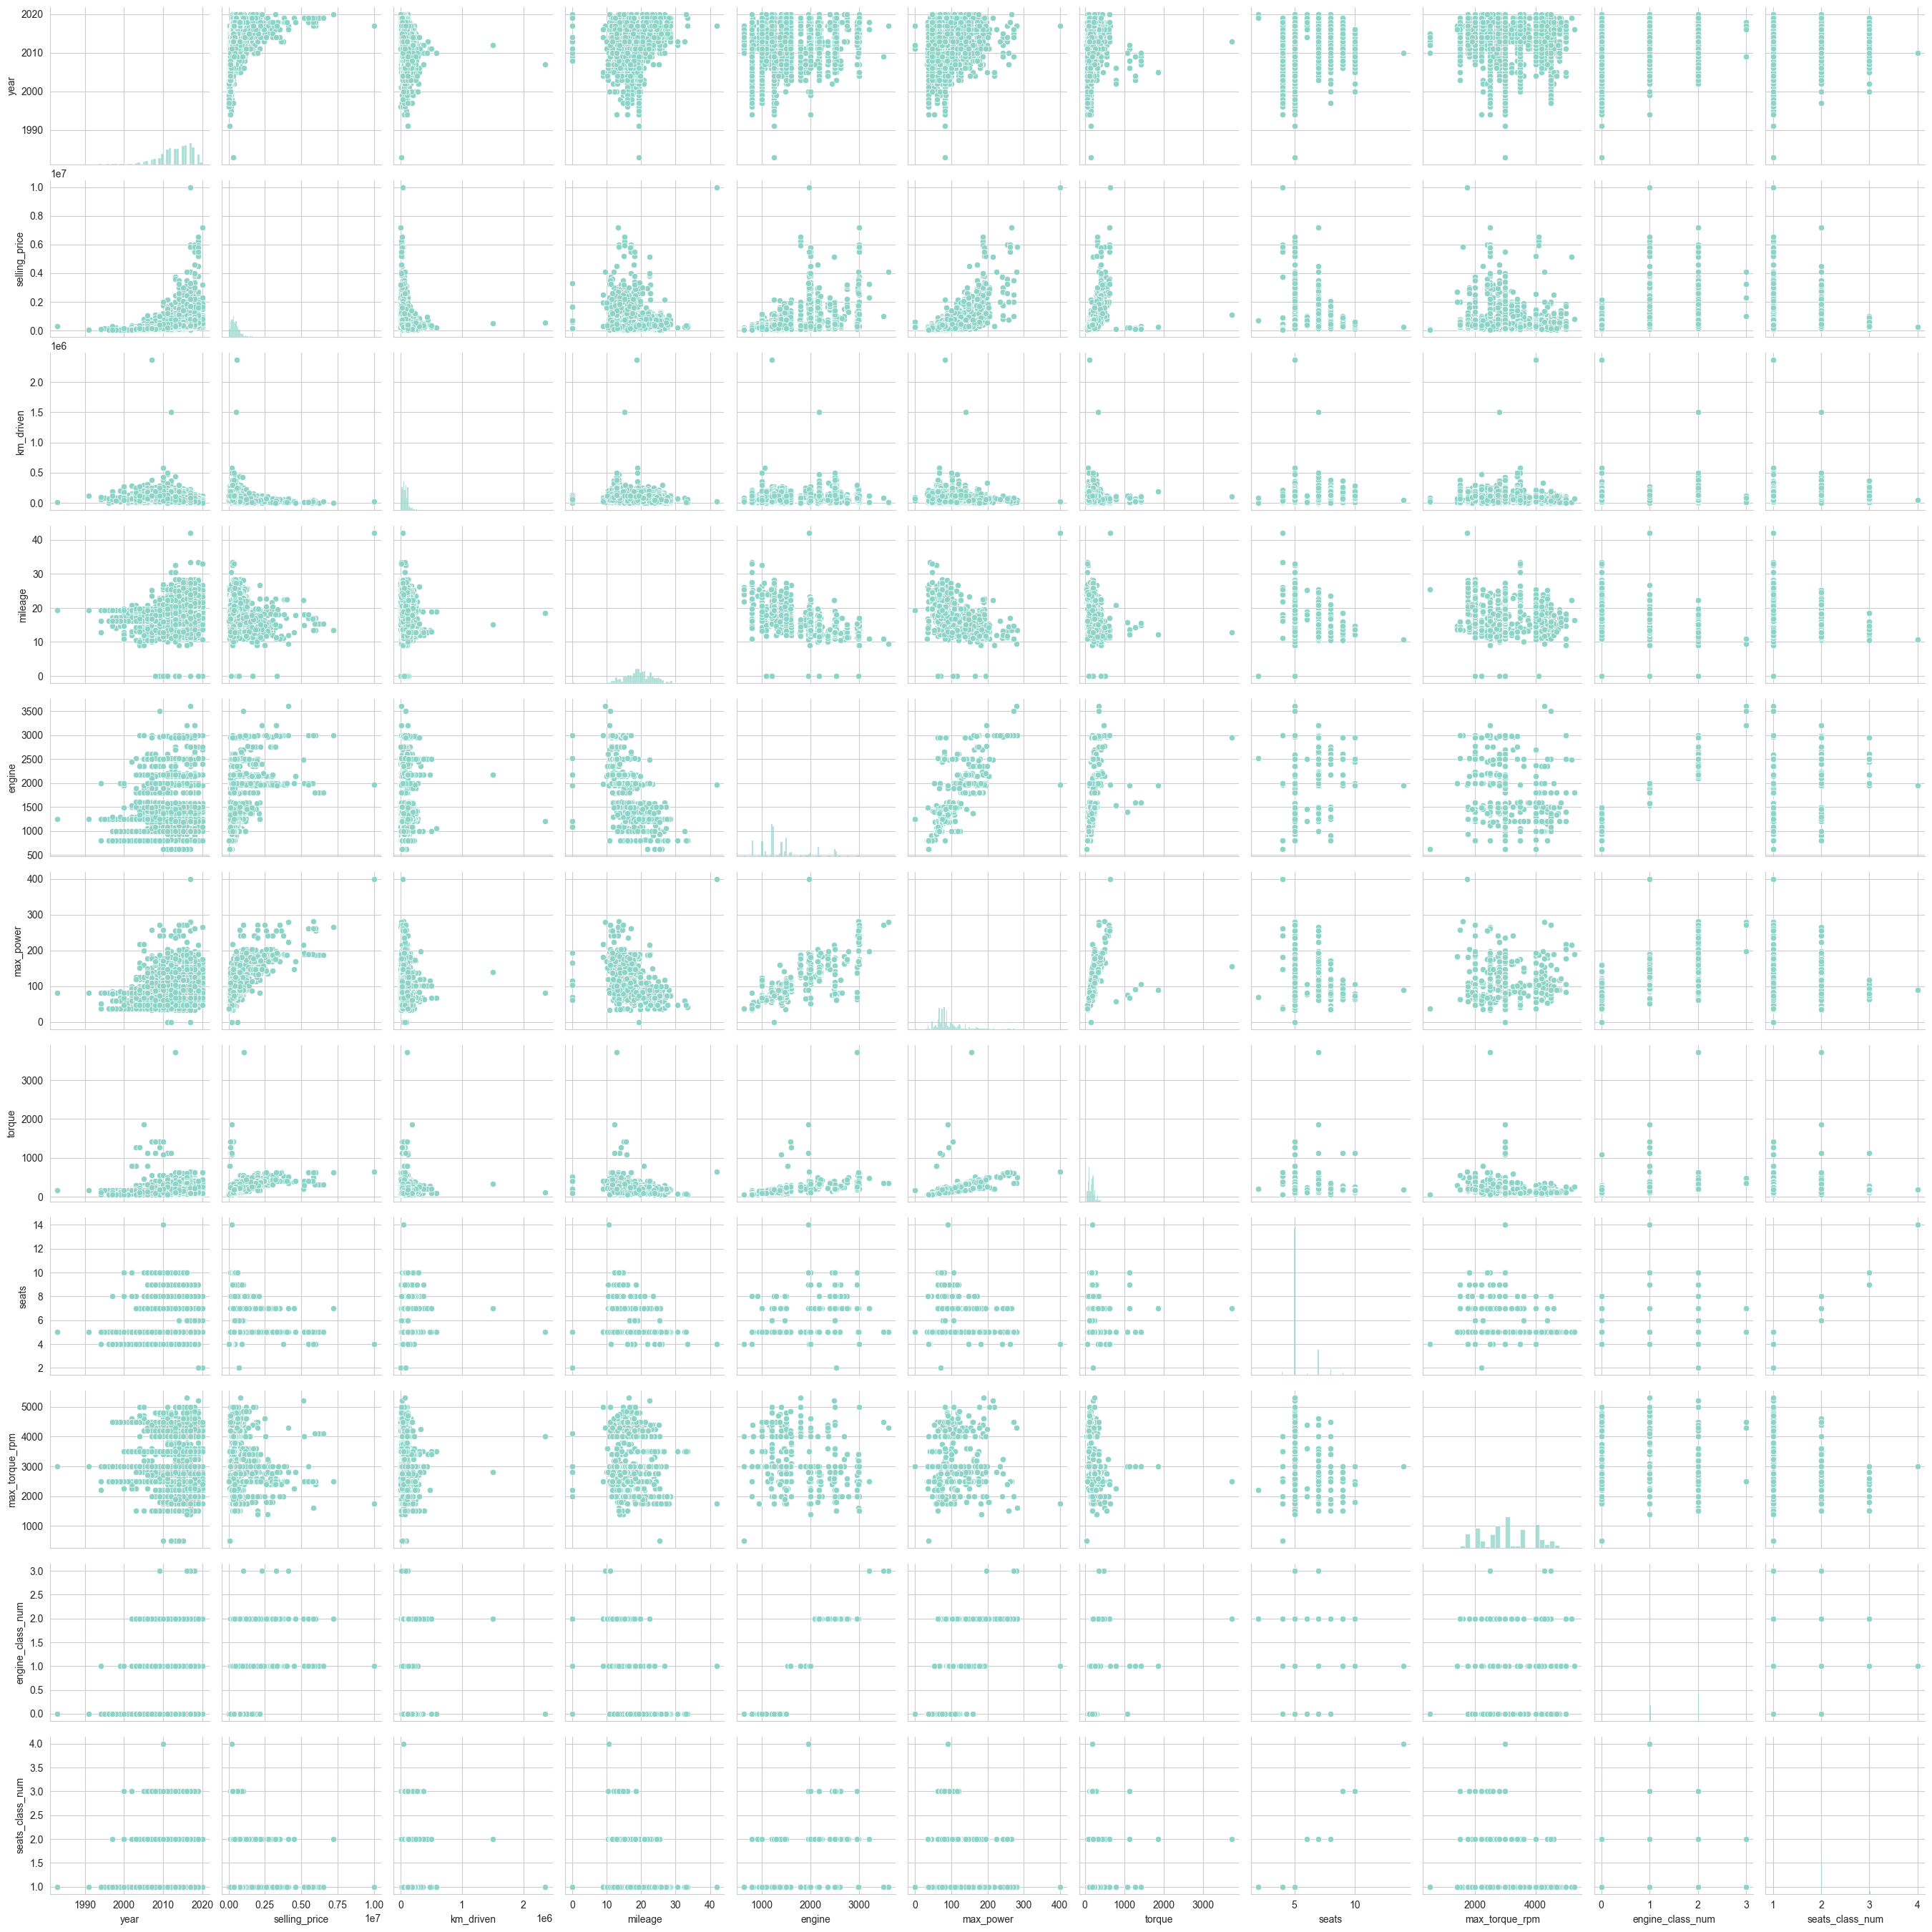

In [68]:
import seaborn as sns

sns.set_style("whitegrid")
sns.pairplot(df_train)

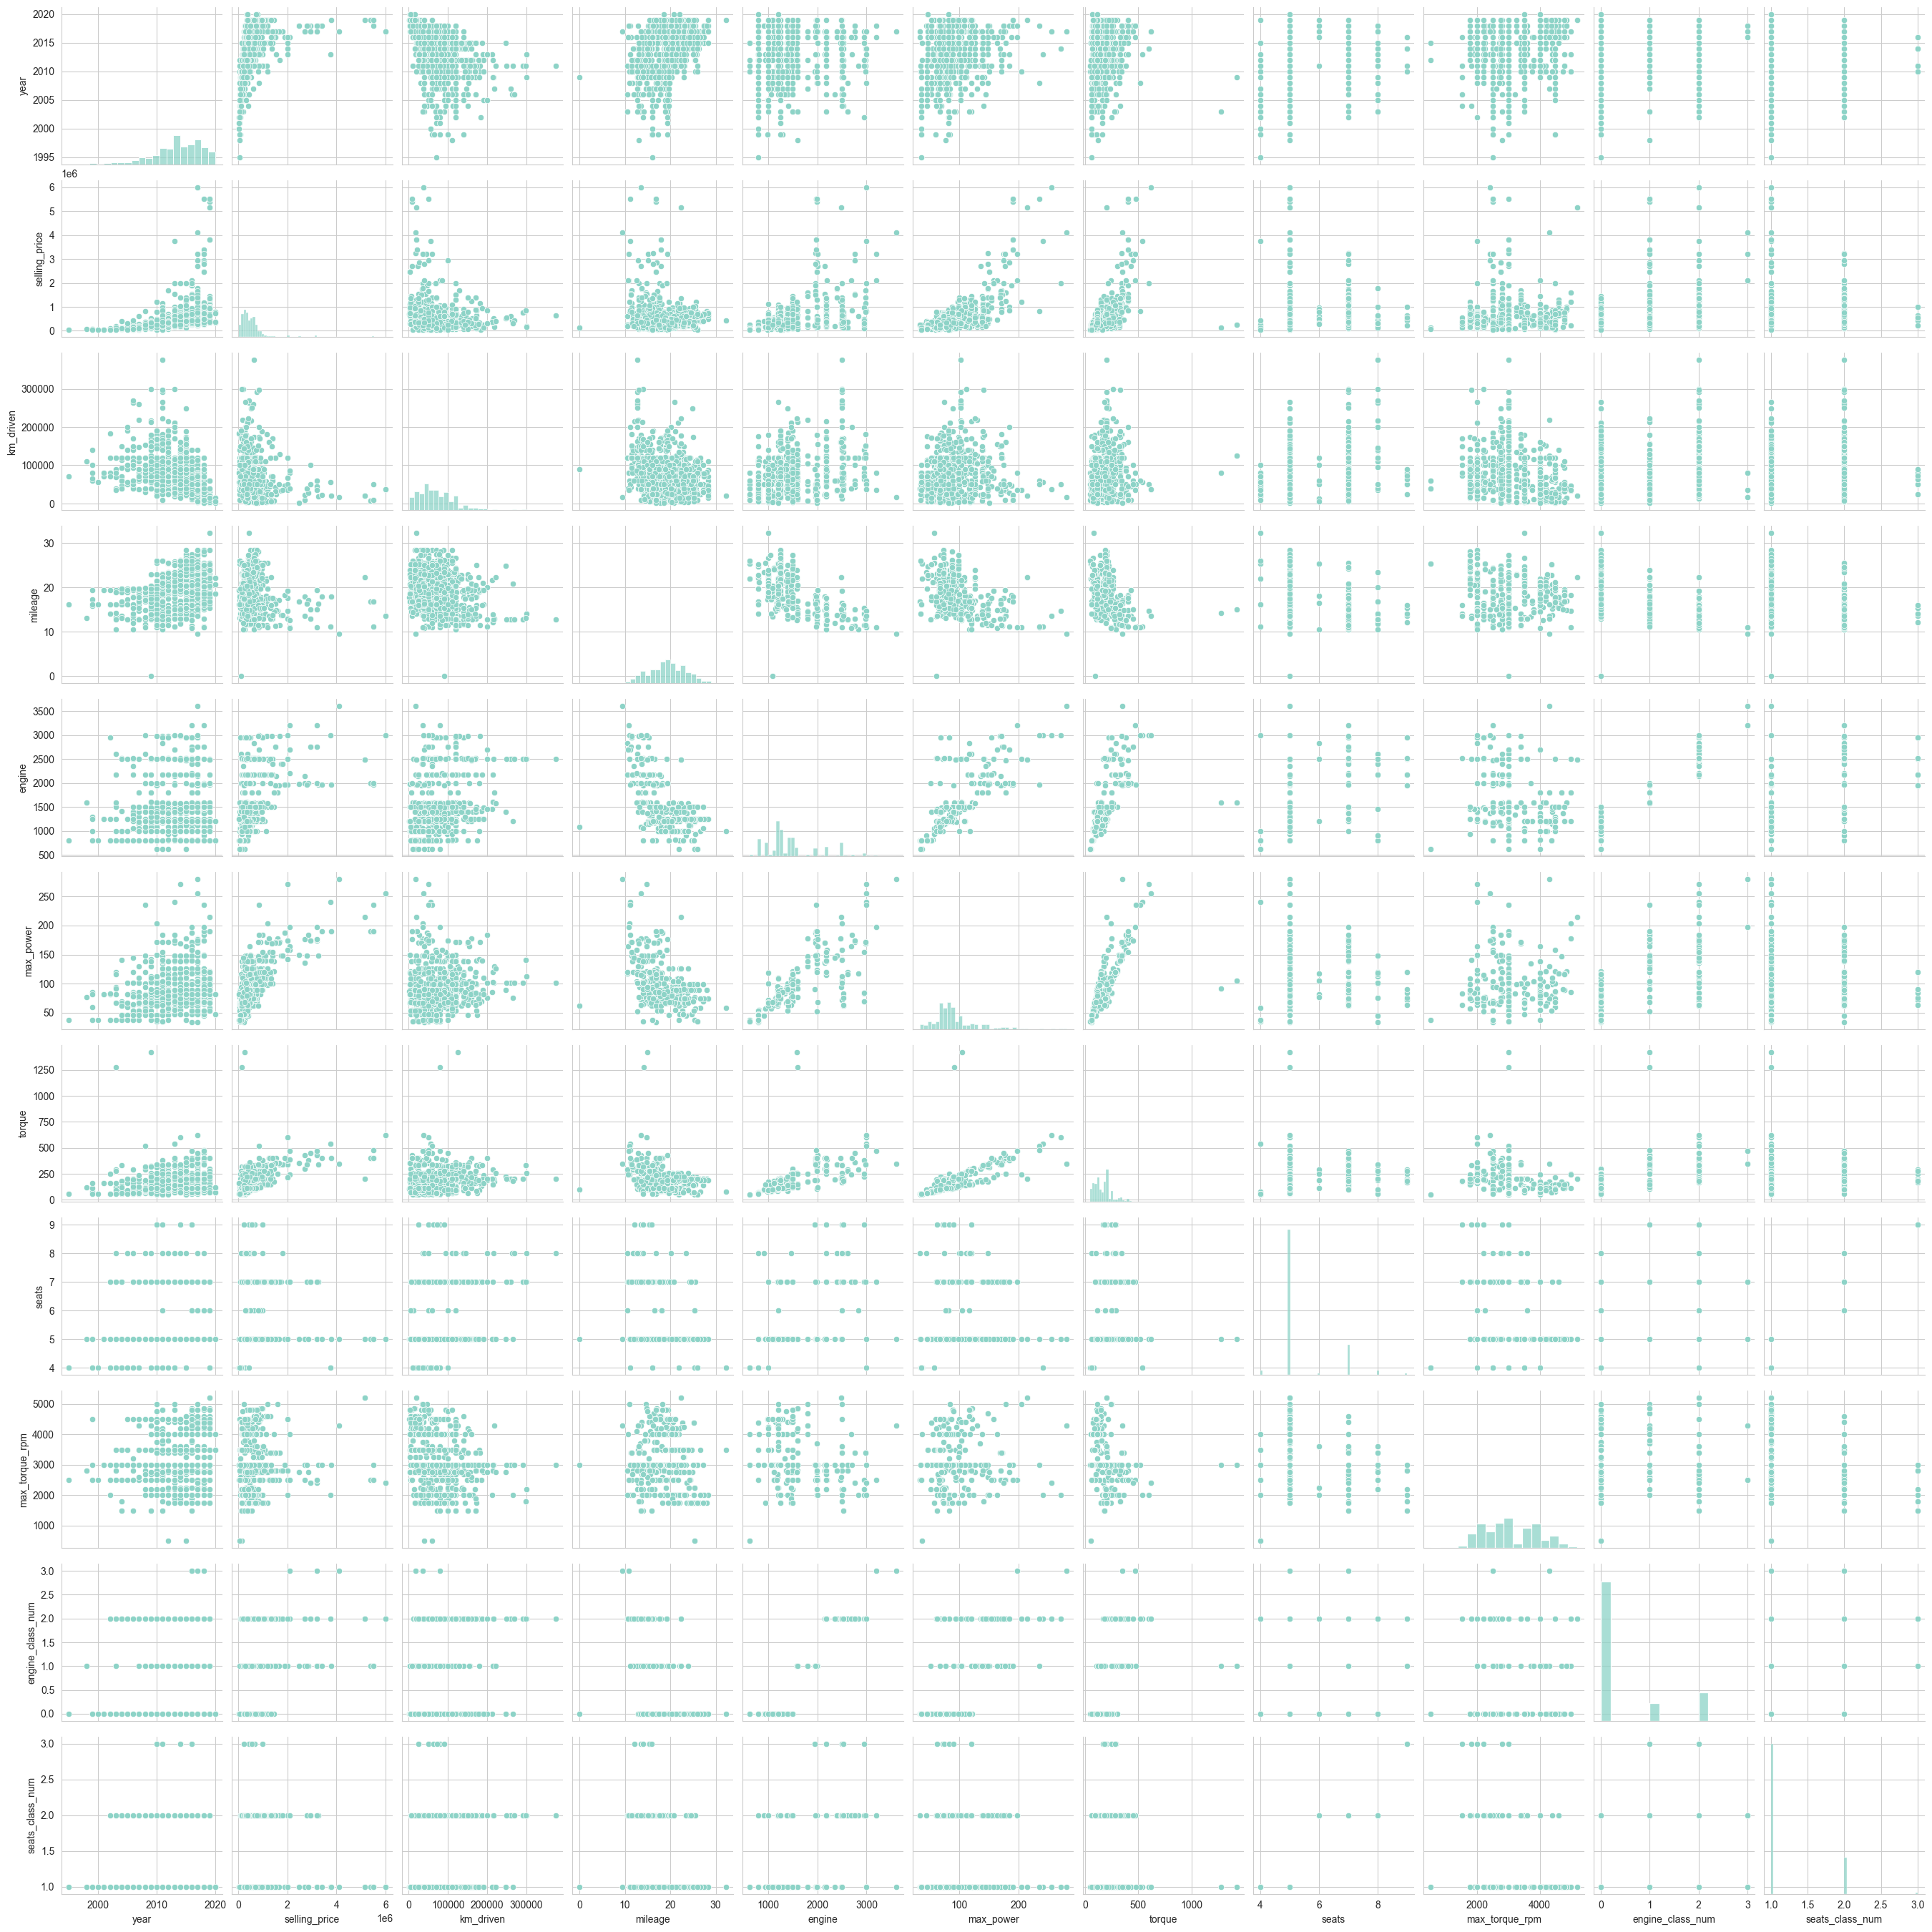

In [69]:
sns.pairplot(df_test)

### Связь признаков с целевой переменной
 Да, можно предположить связь. На графиках видно, что:
   - `year` — чем новее автомобиль, тем выше цена (положительная зависимость, похожа на экспоненциальную/квадратичную)
   - `km_driven` — чем больше пробег, тем ниже цена (отрицательная зависимость)
   - `engine` — больший объём двигателя связан с более высокой ценой
   - `max_power` — наиболее выраженная положительная связь с ценой, чем мощнее автомобиль, тем он дороже
   - `torque` — также положительная связь с ценой

### Гипотезы о корреляциях между признаками:
   - `engine` и `max_power` — сильная положительная корреляция (больше объём → больше мощность)
   - `engine` и `torque` — сильная положительная корреляция
   - `max_power` и `torque` — сильная положительная корреляция
   - `year` и `km_driven` — отрицательная корреляция (новые авто проехали меньше)
   - `mileage` и `engine` — отрицательная корреляция (больше объём → больше расход → меньше mileage)

### Сравнение

Графики трейн и тест примерно совпадают, таким образом мы можем косвенно подтвердить, что данные хорошо распределены как мы и предпологали ранее. Данные корректны, сдвига нет.

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [x] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [x] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

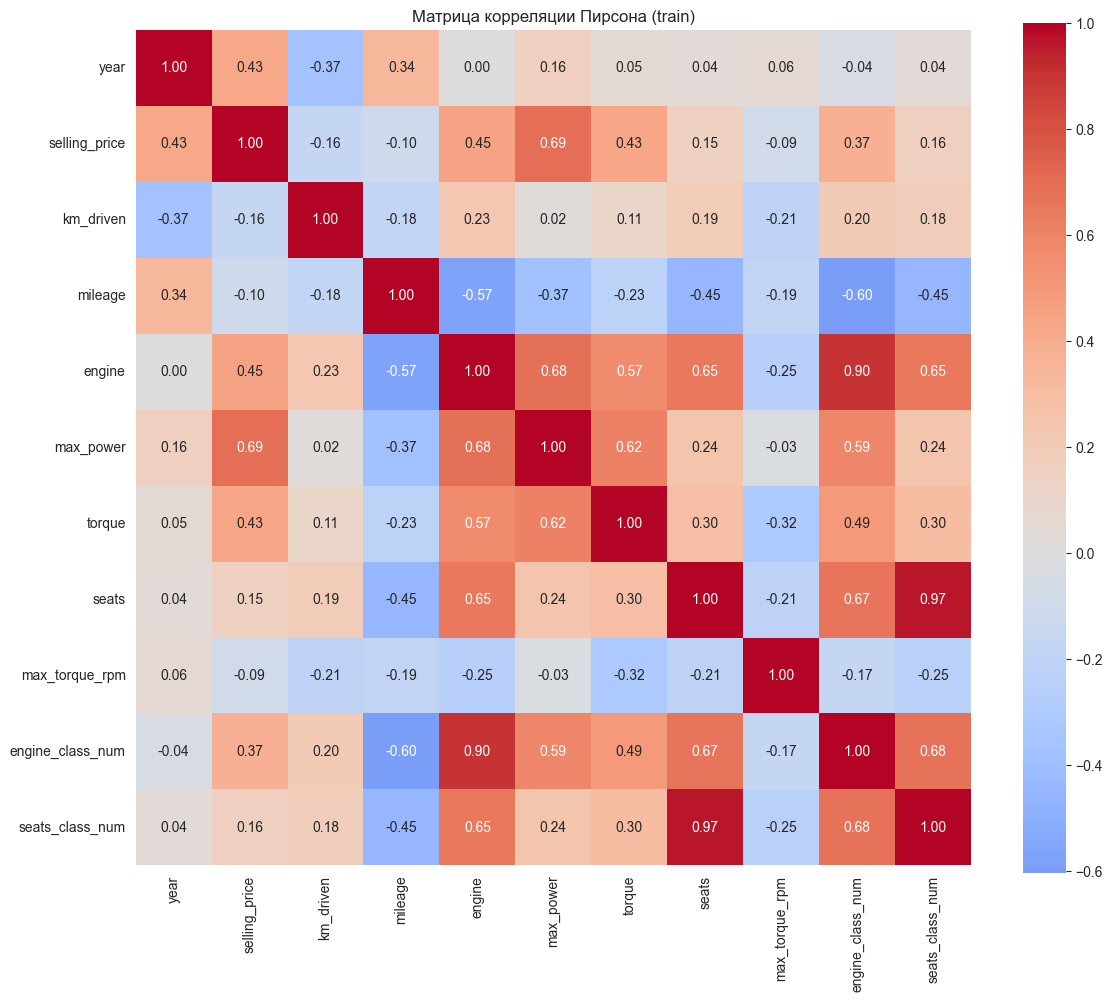

In [70]:
corr_matrix = df_train.select_dtypes(include='number').corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции Пирсона (train)')
plt.tight_layout()
plt.show()

- [x] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

По результатам матрицы корреляции — наименее скоррелированные пары `engine` & `year`, 'engine' & 'torgue', `engine` & `seats`, `engine` & `max_torque_rpm`

Наиболее сильная положительная корреляция наблюдается между:
- `engine` и `max_power` — больший объём двигателя закономерно связан с большей мощностью
- `engine` и `torque` — аналогично, объём двигателя определяет крутящий момент
- `max_power` и `selling_price` — мощность является одним из ключевых факторов цены
- `engint` и его категориальные признаки не берем так как это одно и тоже)))

Чем старше автомобиль, тем больше пробег к моменту продажи. В целом логика подсказывает аналогичный вывод.

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ] Любой возможности говорить "ДА" (если что тут была просто лишняя ячейка)

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


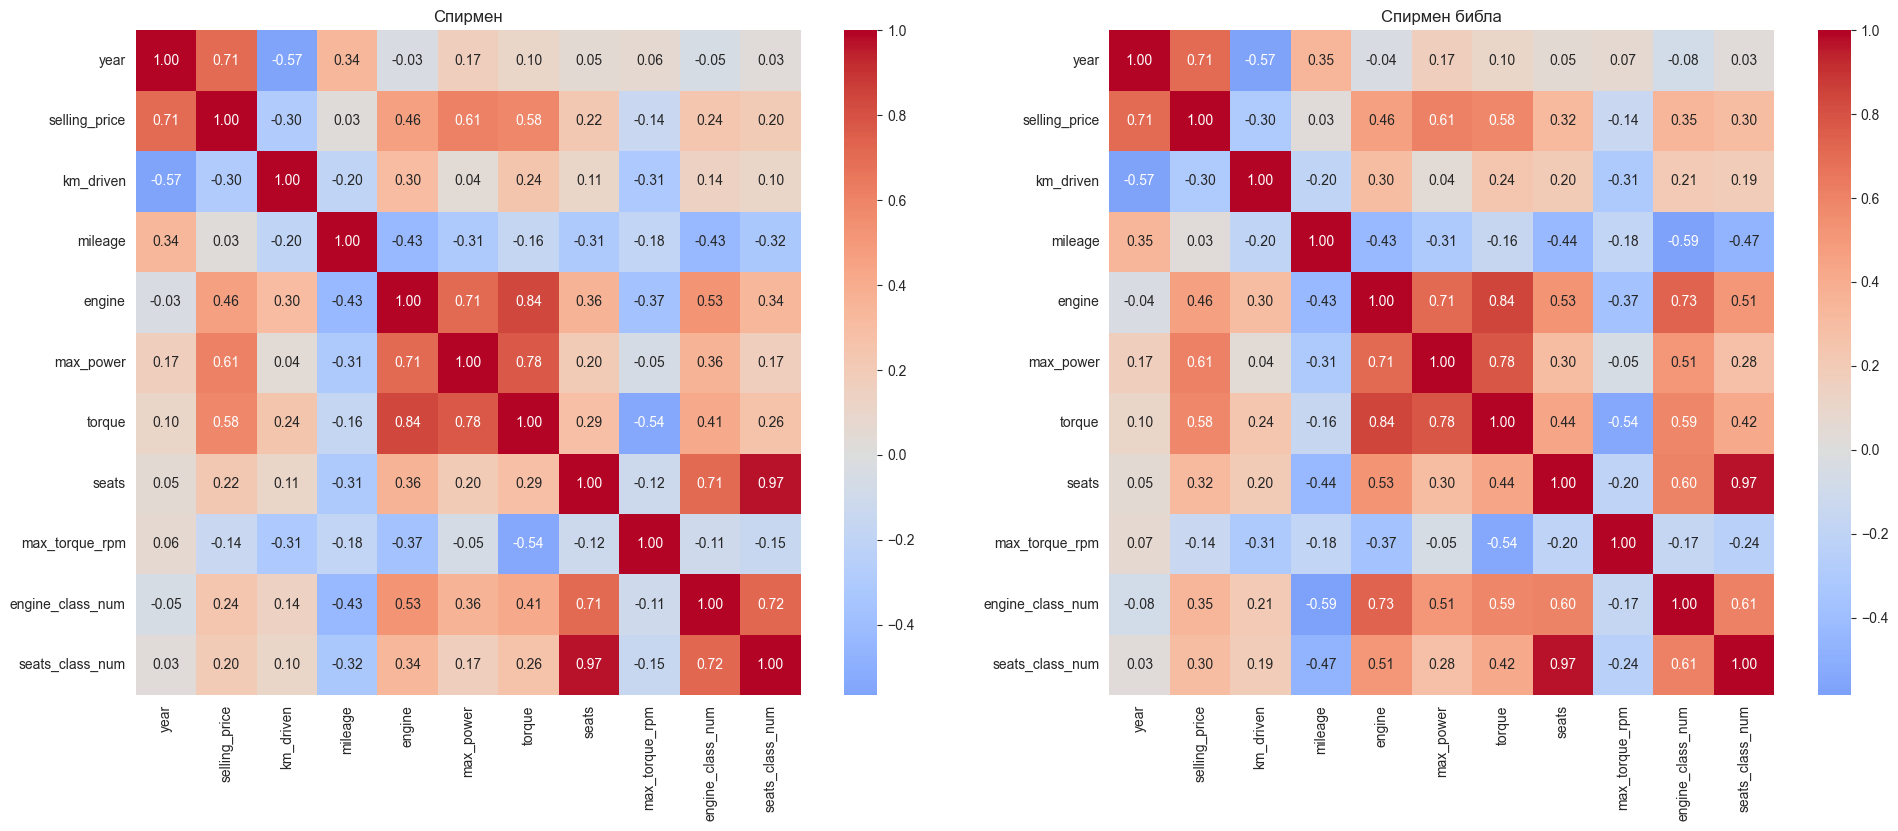

In [71]:
# Спирман вручную -
def spearman_corr(x, y):
    rx = np.argsort(np.argsort(x)).astype(float)
    ry = np.argsort(np.argsort(y)).astype(float)

    num = np.sum((rx - rx.mean()) * (ry - ry.mean()))
    den = np.sqrt(np.sum((rx - rx.mean())**2) * np.sum((ry - ry.mean())**2))
    return num / den

# Строим матрицу вручную
numeric_cols = df_train.select_dtypes(include='number').columns
n = len(numeric_cols)
spearman_manual = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        spearman_manual[i, j] = spearman_corr(df_train[numeric_cols[i]].values, df_train[numeric_cols[j]].values)

spearman_manual_df = pd.DataFrame(spearman_manual, index=numeric_cols, columns=numeric_cols)

# Библа
spearman_lib = df_train[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(spearman_manual_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=axes[0])
axes[0].set_title('Спирмен')
sns.heatmap(spearman_lib, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=axes[1])
axes[1].set_title('Спирмен библа')
plt.tight_layout()
plt.show()

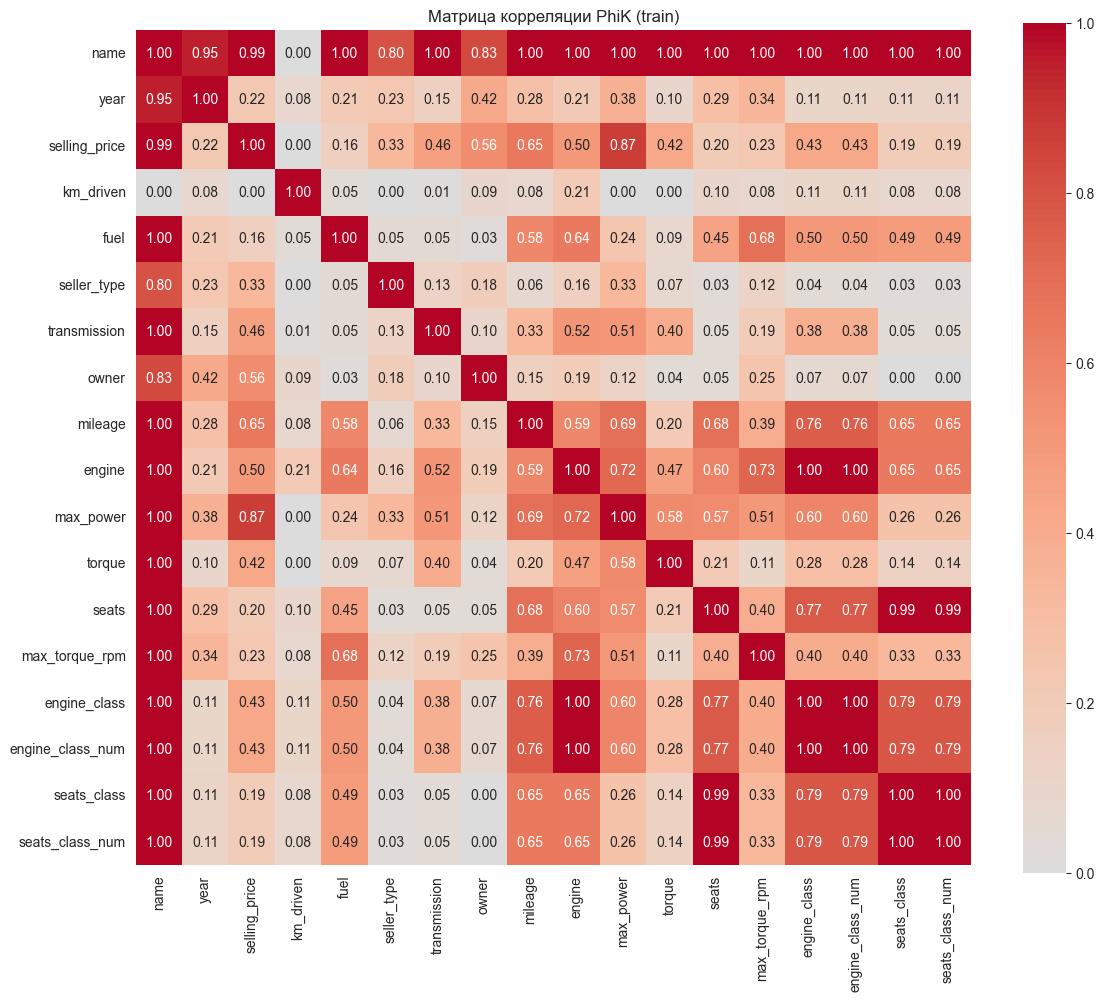

In [72]:
# Матрица корреляции phik
import phik

phik_matrix = df_train.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции PhiK (train)')
plt.tight_layout()
plt.show()

### Интерпретация результатов

Спирмен vs Пирсон: Ручная реализация близка к библиотечной.
Спирмен меряет монотонную зависимость. Значения близки, азанчит зависимости в данных преимущественно монотонные.

PhiK: дал нам дополнительные корреляции но в рамках того что он нам показал -
- название сильно влияет на цену (очевидно)
- трансмисия имеет влияние
- владаелец имеет влияние

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

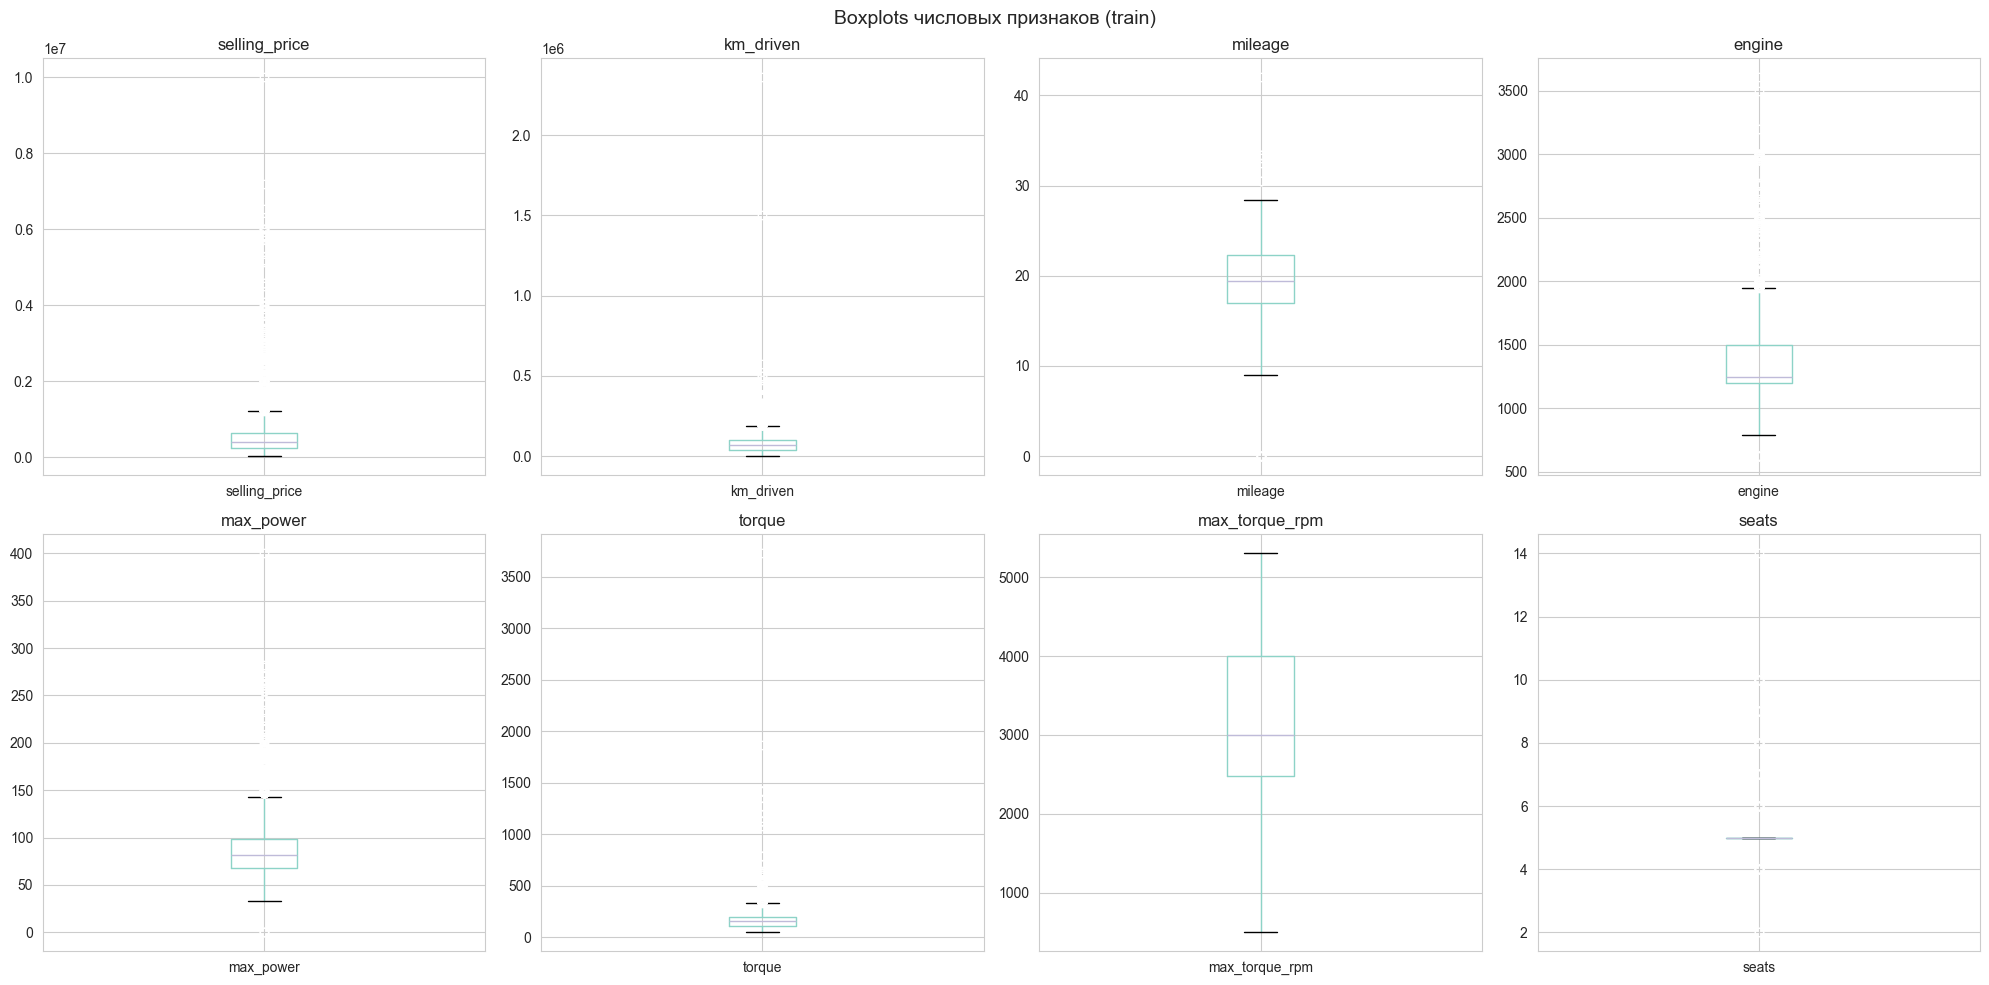

In [73]:
# Boxplots — анализ выбросов
numeric_cols_plot = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm', 'seats']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_plot):
    df_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Boxplots числовых признаков (train)', fontsize=14)
plt.tight_layout()
plt.show()

### Почему boxplots?

Pairplot и heatmap показывают связи между признаками, но не дают четкой картины по выбросам. Boxplot — самый наглядный

- selling_price — очевидные выбросы сверху, подтверждает разницу mean/median в 42% из задания 2
- km_driven — есть авто с аномально большим пробегом (>200k), что может искажать модель
- torque — единичные экстремальные значения, возможно ошибки при парсинге или реально экзотические авто
- mileage — есть нулевые значения, хмммм, подозрительно


# **Часть 2 (5.4 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [74]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']

y_train = df_train['selling_price']
X_train = df_train[numeric_features]

In [75]:
assert X_train.shape == (5840, 8)

In [76]:
y_test = df_test['selling_price']
X_test = df_test[numeric_features]

In [77]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train = MSE(y_train, y_train_pred)
mse_test = MSE(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'R2': [r2_train, r2_test],
    'MSE': [mse_train, mse_test],
}, index = ['train', 'test'])

block_title('Метрики лр')
print(metrics_df)

block_title('Коэф модели')
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values()
print(coefs)

seats            -31362.697979
mileage           -2583.895589
max_torque_rpm      -72.846999
torque              -27.685160
km_driven            -0.820343
engine               46.981033
max_power         10571.570742
year              40697.937052
dtype: float64


В тренировочном и тестовом датасетах r2 сопоставим - модель не переобучилась.
Метрика качества 0.60 - достаточно низкая - нужно растить за счет стандартизации, регуляризация, фичи и тд.

### **Задание 13 (0.45 балла)**

- [x] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [79]:
def r2_manual(y_orig, y_pred):
    y_orig = np.asarray(y_orig) # наше значение таргета
    y_pred = np.asarray(y_pred) # наше предсказание модели
    ss_res = np.sum((y_orig - y_pred)**2) # Сумма квадратов ошибки модели - наша оценка на сколько предсказание отличается от истины
    ss_tot = np.sum((y_orig - np.mean(y_orig))**2) # Сумма квадратов отклонения значений от среднего - наша оценка как сильно цены разбросаны вокруг среднего
    r2 = 1 - ss_res / ss_tot # Собственно r2
    return r2

### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [80]:
def adj_r2(y_true, y_pred, a_features):
    items = len(y_true)
    r2 = r2_manual(y_true, y_pred)
    adj_r2_r = 1 - (1 - r2) * (items - 1) / (items - a_features - 1)
    return adj_r2_r

p = X_train.shape[1]

adj_r2_train = adj_r2(y_train, y_train_pred, p)
adj_r2_test = adj_r2(y_test, y_test_pred, p)

metrics_adj_df = pd.DataFrame({
    'R2': [r2_train, r2_test],
    'adj_R2': [adj_r2_train, adj_r2_test],
}, index=['train', 'test'])

block_title('R2 vs adjusted R2')
print(metrics_adj_df)


             R2    adj_R2
train  0.601305  0.600758
test   0.600571  0.597347


### Формула

R2(adj) = 1 - (1 - R2) * (n-1)/(n - p - 1)

- n - число объектов
- p - число признаков, которые скормили модели
- R² - наш обычный r2_manual

Множитель (n-1)/(n-p-1) - штраф за лишние фичи. Чем больше p, тем сильнее эта дробь больше единицы и тем сильнее adj_R² проседает относительно R².

### Когда нужен adj_R²

Обычный R² при добавлении любого нового признака не убывает - даже если признак шумовой. Поэтому по нему нельзя честно сравнивать модели с разным числом фич, модель с кучей признаков всегда будет выглядеть не хуже.

Adj_R² это чинит - добавили признак, R² подрос мало - метрика упадет.

Используем когда:

- сравниваем модели с разным количеством признаков (отбор фич, регуляризация, OHE и тд)
- мало данных и много фич - тут обычный R² особенно врет
- хотим понять, реально ли новые фичи помогают или модель просто подгоняется под шум

В отличие от R² adj_R² может быть отрицательным и может уменьшаться при добавлении признаков - это нормально и собственно ради этого он и нужен.


### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Обучаем только на train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Заново учим лр на стандартизированных фичах
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

y_train_pred_scaled = lr_scaled.predict(X_train_scaled)
y_test_pred_scaled = lr_scaled.predict(X_test_scaled)

r2_train_scaled = r2_score(y_train, y_train_pred_scaled)
r2_test_scaled = r2_score(y_test, y_test_pred_scaled)
mse_train_scaled = MSE(y_train, y_train_pred_scaled)
mse_test_scaled = MSE(y_test, y_test_pred_scaled)

metrics_scaled_df = pd.DataFrame({
    'R2_raw':     [r2_train,         r2_test],
    'R2_scaled':  [r2_train_scaled,  r2_test_scaled],
    'MSE_raw':    [mse_train,        mse_test],
    'MSE_scaled': [mse_train_scaled, mse_test_scaled],
}, index=['train', 'test'])

block_title('До и после стандартизации')
print(metrics_scaled_df)


         R2_raw  R2_scaled       MSE_raw    MSE_scaled
train  0.601305   0.601305  1.142812e+11  1.142812e+11
test   0.600571   0.600571  2.296031e+11  2.296031e+11


Качество не изменилось - R² и MSE на train и test одинаковые

LinearRegression инвариантна к линейному масштабированию признаков - стандартизация просто сдвигает и сжимает фичи, а регрессия пересчитает коэффициенты обратно и выдаст те же самые предсказания.

Предел совершенства кажется не был достигнут

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [82]:
cofs_scaled = pd.Series(lr_scaled.coef_, index=X_train.columns)
coefs_ranked = cofs_scaled.reindex(cofs_scaled.abs().sort_values(ascending=False).index)
print(coefs_ranked)

max_power         334460.281652
year              166669.092648
max_torque_rpm    -62917.598687
km_driven         -49274.738427
seats             -30806.318754
engine             22814.988023
mileage           -10298.456639
torque             -3232.167258
dtype: float64


Наиболее информативным является `max_power`, что повторяет результаты матрицы корелляции.

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [83]:
from sklearn.linear_model import Lasso

lasso = Lasso(random_state=0)
lasso.fit(X_train_scaled, y_train)

y_train_pred_l = lasso.predict(X_train_scaled)
y_test_pred_l = lasso.predict(X_test_scaled)

lasso_metrics = pd.DataFrame({
    'R2': [r2_score(y_train, y_train_pred_l), r2_score(y_test, y_test_pred_l)],
    'MSE': [MSE(y_train, y_train_pred_l), MSE(y_test, y_test_pred_l)],
}, index=['train', 'test'])

lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
block_title("Коэфициенты Лассо")
print(lasso_coefs)
block_title("Зануленные Лассо")
print(f"{(lasso_coefs == 0).sum()}")

0


Lasso не занулил ни одного коэффициента, все признаки отсались в модели.

Меньше всего вес имеет `torque`. Предположение - наверное потому что нужно поднимать альфа.

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [91]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

alpha_lasso = np.logspace(-1, 6, 30)

lasso_grid = GridSearchCV(
    estimator=Lasso(random_state=RANDOM_STATE, max_iter=10000),
    param_grid={'alpha': alpha_lasso},
    cv=10,
    scoring='r2',
    n_jobs=-1,
)
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
y_train_pred = best_lasso.predict(X_train_scaled)
y_test_pred = best_lasso.predict(X_test_scaled)

print(f"Best alpha {lasso_grid.best_params_['alpha']:.4g}")
print(f"Best CV R2:", lasso_grid.best_score_)
print(f"Test R2:", r2_score(y_test, lasso_grid.predict(X_test_scaled)))
print(f"Test MSE:", MSE(y_test, lasso_grid.predict(X_test_scaled)))

from sklearn.linear_model import ElasticNet

en_grid = GridSearchCV(
    estimator=ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    param_grid={'alpha': alpha_lasso,
                'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
                },
    cv=10,
    scoring = 'r2',
    n_jobs=-1,
)
en_grid.fit(X_train_scaled, y_train)

best_en = en_grid.best_estimator_
y_train_pred = best_en.predict(X_train_scaled)
y_test_pred = best_en.predict(X_test_scaled)

n_combos = len(en_grid.cv_results_['params'])
n_fits = n_combos * 10 + 1
bp = en_grid.best_params_

print('Комбинаций:', n_combos)
print(f"Всего обучений:", n_fits)
print(f"Alpha: {bp['alpha']:.4g}")
print(f"L1_ratio: {bp['l1_ratio']}")
print(f"Best CV R2:    {en_grid.best_score_:.4f}")
print(f"Train R2: {r2_score(y_train, y_train_pred):.4g}")
print(f"Test R2: {r2_score(y_test, y_test_pred):.4g}")
print(f"Train MSE:     {MSE(y_train, y_train_pred):.4e}")
print(f"Test  MSE:     {MSE(y_test,  y_test_pred):.4e}")

Комбинаций: 150
Всего обучений: 1501
Alpha: 0.9237
L1_ratio: 0.9
Best CV R2:    0.5810
Train R2: 0.5962
Test R2: 0.5789
Train MSE:     1.1575e+11
Test  MSE:     2.4207e+11


Перебирали `alpha` по логарифмической сетке `np.logspace(-1, 6, 30)` - 30 точек на 7 порядков. Этого достаточно: best alpha оказался в середине диапазона (~2e+04), не на
  краю, расширять сетку нет смысла.

  Best alpha = 2.04e+04, CV R² = 0.58, Test R² = 0.58 - между CV и тестом расхождения нет, переобучения по гиперпараметру не случилось.

  Качество практически совпало с обычной LinearRegression (R² ≈ 0.60), даже чуть просело. Это ожидаемо - на 8 фичах модель и так не переобучена (train ≈ test было ещё в задании 12), сжимать веса L1 нечего, регуляризация только мешает.

  L1 при оптимальном alpha занулил 0 признаков из 8 - вот это уже полезно как побочный продукт, можно использовать для отбора фичей.

**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

В `param_grid` Lasso только один параметр — `alpha`. Это коэффициент силы L1-регуляризации в формуле `L = MSE + alpha * Σ|β_j|`. При alpha=0 модель совпадает с обычным методом по наименьши квадратам, при больших alpha штраф давит коэффициенты к нулю.

  Перебирали 30 значений по логарифмической сетке `np.logspace(-1, 6, 30)` — 30 точек на 7 порядков. Best alpha оказался в середине диапазона (~2e+04), не на краю, сетку расширять не нужно.

  Всего обучений: 30 alpha × 10 фолдов + 1 финальный refit на полном train = 301 модель.

  Best alpha = 2.04e+04, CV R² = 0.58, Test R² = 0.58 — между CV и тестом расхождения нет, переобучения по гиперпараметру не случилось.

  L1 при оптимальном alpha занулил 0 признаков из 8. Качество практически совпало с обычной LinearRegression (R² ≈ 0.60). Это ожидаемо: на 8 фичах модель и так не переобучена, сжимать веса L1 нечего.

  Cell 85 (ElasticNet):

  Сетка: 30 alpha × 5 l1_ratio = 150 комбинаций. Каждая проверена 10-фолдовой CV → 1500 обучений + 1 финальный refit на полном train с лучшими параметрами = 1501 модель.

  Лучшие гиперпараметры:
  - alpha = 0.9237
  - l1_ratio = 0.9
  - CV R² = 0.5810
  - Test R² = 0.5789

  l1_ratio = 0.9 означает, что в смеси штрафа доминирует L1 (90% L1 + 10% L2) — модель работает почти как Lasso. Малое alpha (~1) при таком распределении говорит, что для
  качества выгоднее почти не штрафовать. Это согласуется с выводом задания 16: на 8 фичах регуляризация не помогает.

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [92]:
from sklearn.linear_model import LinearRegression

def l0_best_subset(X_tr, y_tr, X_te, y_te, alpha):
    p = X_tr.shape[1]
    best = {'loss': np.inf}

    for mask in range(2 ** p):
        cols = [j for j in range(p) if (mask >> j) & 1]
        k = len(cols)

        if k == 0:
            pred_tr = np.full(len(y_tr), y_tr.mean())
            pred_te = np.full(len(y_te), y_tr.mean())
        else:
            lr = LinearRegression().fit(X_tr[:, cols], y_tr)
            pred_tr = lr.predict(X_tr[:, cols])
            pred_te = lr.predict(X_te[:, cols])

        mse_tr = MSE(y_tr, pred_tr)
        loss = mse_tr + alpha * k

        if loss < best['loss']:
            best = {
                'loss': loss, 'subset': tuple(cols), 'k': k,
                'r2_test': r2_score(y_te, pred_te) if k > 0 else 0.0,
                'mse_test': MSE(y_te, pred_te),
            }
    return best


feature_names = X_train.columns.tolist()
y_tr = y_train.values
y_te = y_test.values

print(f"{'alpha':>10} | {'k':>2} | {'R2_test':>8} | features")
print('-' * 80)
for alpha in [0, 1e8, 1e9, 1e10, 1e11, 1e12, 1e13]:
    res = l0_best_subset(X_train_scaled, y_tr, X_test_scaled, y_te, alpha)
    selected = [feature_names[i] for i in res['subset']]
    print(f"{alpha:>10.0e} | {res['k']:>2} | {res['r2_test']:>8.4f} | {selected}")


     1e+11 |  1 |   0.5128 | ['max_power']
     1e+12 |  0 |   0.0000 | []
     1e+13 |  0 |   0.0000 | []


L0 = число ненулевых коэффициентов: `L = MSE + α * ||β||_0`. Невыпуклая, в sklearn нет — реализовал перебором всех 2^8 = 256 подмножеств фичей (best subset selection).

Что показал эксперимент:
- При α = 0 — берутся все 8 фичей, R²_test ≈ 0.60 (это обычная МНК).
- При средних α — модель отбрасывает наименее значимые фичи (torque, mileage), R² проседает на 0.01–0.02.
- При больших α — остаётся 1 фича `max_power`, что подтверждает результат задания 15.
- При очень больших α — оптимум пустое подмножество (предсказание = среднее), R² = 0.

В отличие от L1, L0 не сжимает коэффициенты у выживших — у выбранного подмножества это обычные МНК-веса.

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [93]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']
cat_features = ['name', 'fuel', 'seller_type', 'transmission', 'owner']

X_train_cat = df_train[numeric_features + cat_features].copy()
X_test_cat  = df_test[numeric_features + cat_features].copy()

# Берём только бренд (первое слово)
X_train_cat['name'] = X_train_cat['name'].str.split().str[0]
X_test_cat['name']  = X_test_cat['name'].str.split().str[0]

print('Уникальных брендов в train:', X_train_cat['name'].nunique())
print('Уникальных брендов в test:',  X_test_cat['name'].nunique())
print('\nТоп брендов в train:')
print(X_train_cat['name'].value_counts().head(10))

unseen = set(X_test_cat['name']) - set(X_train_cat['name'])
print(f'\nБрендов в test, отсутствующих в train: {len(unseen)} -> {unseen}')

Уникальных брендов в train: 30
Уникальных брендов в test: 25

Топ брендов в train:
name
Maruti        1804
Hyundai       1058
Mahindra       611
Tata           534
Toyota         309
Ford           308
Honda          308
Chevrolet      188
Renault        171
Volkswagen     153
Name: count, dtype: int64

Брендов в test, отсутствующих в train: 2 -> {'Ashok', 'Opel'}


In [94]:
assert X_train_cat.shape == (5840, 13)

In [95]:
X_train_cat.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,30,4,3,2,5
top,Maruti,Diesel,Individual,Manual,First Owner
freq,1804,3177,5223,5336,3603


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [96]:
from sklearn.preprocessing import OneHotEncoder

ohe_features = ['seats', 'name', 'fuel', 'seller_type', 'transmission', 'owner']
num_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_cat[ohe_features])

ohe_cols = ohe.get_feature_names_out(ohe_features)

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_cat[ohe_features]),
    columns=ohe_cols, index=X_train_cat.index,
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_cat[ohe_features]),
    columns=ohe_cols, index=X_test_cat.index,
)

X_train_full = pd.concat(
    [X_train_cat[num_features].reset_index(drop=True),
     X_train_ohe.reset_index(drop=True)], axis=1
)
X_test_full = pd.concat(
    [X_test_cat[num_features].reset_index(drop=True),
     X_test_ohe.reset_index(drop=True)], axis=1
)

print('Train shape:', X_train_full.shape)
print('Test shape: ', X_test_full.shape)
print('Колонок после OHE:', X_train_full.shape[1])

/Users/mirael_mini/miniconda3/envs/HSE/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

Для корректной работы с OHE необходмо сначала подумать о редких категориях, редкие итемы лучше определять в общую группу например.

Тренировать стоит только на тренировочном датасете, а трансформировать уже на всех (тренировочный, отладочный, валидационный и иные).
Сохранять только с одинаковой кодировкой.
Нужно предусматривать поведение при котором к нам попадут новые итемы которых мы ранее не встречали и соответсвенно нужно предусмотреть, что бы мы не падали.


Удаление одного столбца - нужно для того что бы не попасть в 'dummy variable trap'. Идея в том, что бы подстраховаться от ситуации где у нас модель обучится на одной и тойже переменной и несколько переменных могут быть колинеарны, что создаст для нас проблему.

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [97]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pied_piper = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=RANDOM_STATE)),
])

param_grid = {'ridge__alpha': np.logspace(-3, 6, 40)}

ridge_grid = GridSearchCV(
    pied_piper,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
)
ridge_grid.fit(X_train_full, y_train)

best_ridge = ridge_grid.best_estimator_
y_train_pred = best_ridge.predict(X_train_full)
y_test_pred  = best_ridge.predict(X_test_full)

print(f"Best alpha: {ridge_grid.best_params_['ridge__alpha']:.4g}")
print(f"Best CV R2: {ridge_grid.best_score_:.4f}")
print(f"Train R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R2:   {r2_score(y_test,  y_test_pred):.4f}")
print(f"Train MSE:  {MSE(y_train, y_train_pred):.4e}")
print(f"Test  MSE:  {MSE(y_test,  y_test_pred):.4e}")


Best alpha: 587.8
Best CV R2: 0.7096
Train R2:   0.7701
Test  R2:   0.7812
Train MSE:  6.5886e+10
Test  MSE:  1.2576e+11


Используем Pipeline (StandardScaler -> Ridge), чтобы избежать утечки в CV: скейлер обучается на каждом тренировочном фолде отдельно, не "видит" валидационный фолд. Перебор alpha по `np.logspace(-3, 6, 40)`.

Качество выросло с ~0.60 (8 числовых фич) до ~0.78 - категориальные признаки (бренд, тип топлива, владелец, число мест) несут полезный сигнал, не покрываемый числовыми.

Ridge с L2-штрафом справляется с разросшимся пространством (~50 OHE-колонок) и сглаживает разброс весов между скоррелированными категориями (например, между разными брендами одной ценовой категории).

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [99]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def add_basic_fe(df):
    df = df.copy()
    df['car_age'] = 2025 - df['year']
    df['car_age_sq'] = df['car_age'] ** 2
    df['power_per_cc'] = df['max_power'] / df['engine']
    df['usage_per_year'] = df['km_driven'] / df['car_age'].replace(0, 1)
    return df

df_train_fe = add_basic_fe(df_train)
df_test_fe  = add_basic_fe(df_test)

# Квантили считаем ТОЛЬКО по train, потом применяем на оба
q20 = df_train_fe['usage_per_year'].quantile(0.2)
q80 = df_train_fe['usage_per_year'].quantile(0.8)

def to_wear(s):
    return pd.cut(s, bins=[-np.inf, q20, q80, np.inf], labels=[0, 1, 2]).astype(int)

df_train_fe['wear_class'] = to_wear(df_train_fe['usage_per_year'])
df_test_fe['wear_class']  = to_wear(df_test_fe['usage_per_year'])

print('Распределение wear_class в train:')
print(df_train_fe['wear_class'].value_counts().sort_index())
print('\nСредняя цена по классам:')
print(df_train_fe.groupby('wear_class')['selling_price'].mean())

num_features_fe = ['car_age', 'car_age_sq', 'km_driven', 'mileage',
                   'engine', 'max_power', 'torque', 'max_torque_rpm',
                   'power_per_cc']
cat_features_fe = ['name', 'fuel', 'seller_type', 'transmission',
                   'owner', 'engine_class', 'seats_class', 'wear_class']

X_train_fe = df_train_fe[num_features_fe + cat_features_fe].copy()
X_test_fe  = df_test_fe[num_features_fe + cat_features_fe].copy()
X_train_fe['name'] = X_train_fe['name'].str.split().str[0]
X_test_fe['name']  = X_test_fe['name'].str.split().str[0]

# Log-таргет
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# OHE
ohe_fe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_fe.fit(X_train_fe[cat_features_fe])
ohe_cols_fe = ohe_fe.get_feature_names_out(cat_features_fe)

X_train_ohe_fe = pd.DataFrame(ohe_fe.transform(X_train_fe[cat_features_fe]),
                              columns=ohe_cols_fe, index=X_train_fe.index)
X_test_ohe_fe  = pd.DataFrame(ohe_fe.transform(X_test_fe[cat_features_fe]),
                              columns=ohe_cols_fe, index=X_test_fe.index)

X_train_full_fe = pd.concat([X_train_fe[num_features_fe].reset_index(drop=True),
                             X_train_ohe_fe.reset_index(drop=True)], axis=1)
X_test_full_fe  = pd.concat([X_test_fe[num_features_fe].reset_index(drop=True),
                             X_test_ohe_fe.reset_index(drop=True)], axis=1)

print(f'\nИтого фичей: {X_train_full_fe.shape[1]}')

# Ridge GridSearch на log-таргете
pipe_fe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=RANDOM_STATE)),
])
ridge_grid_fe = GridSearchCV(
    pipe_fe,
    param_grid={'ridge__alpha': np.logspace(-6, 6, 40)}, # При (-3, 6, 40)   alpha была - 0.001
    cv=10, scoring='r2', n_jobs=-1,
)
ridge_grid_fe.fit(X_train_full_fe, y_train_log)

# Метрики на исходной шкале (rupees)
y_train_pred = np.expm1(ridge_grid_fe.predict(X_train_full_fe))
y_test_pred  = np.expm1(ridge_grid_fe.predict(X_test_full_fe))

print(f"\nBest alpha: {ridge_grid_fe.best_params_['ridge__alpha']:.4g}")
print(f"Train R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R2:   {r2_score(y_test,  y_test_pred):.4f}")
print(f"Test MSE:   {MSE(y_test, y_test_pred):.4e}")


Best alpha: 1e-06
Train R2:   0.9142
Test  R2:   0.9301
Test MSE:   4.0178e+10


In [107]:
# Внутреннее любопытство, что мы тут нафантазировали
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def evaluate(num_feats, cat_feats, use_log=True):
  X_tr = df_train_fe[num_feats + cat_feats].copy()
  X_te = df_test_fe[num_feats + cat_feats].copy()
  X_tr['name'] = X_tr['name'].str.split().str[0]
  X_te['name'] = X_te['name'].str.split().str[0]

  ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
  ohe.fit(X_tr[cat_feats])
  cols = ohe.get_feature_names_out(cat_feats)

  X_tr_ohe = pd.DataFrame(ohe.transform(X_tr[cat_feats]), columns=cols, index=X_tr.index)
  X_te_ohe = pd.DataFrame(ohe.transform(X_te[cat_feats]), columns=cols, index=X_te.index)

  X_tr_full = pd.concat([X_tr[num_feats].reset_index(drop=True),
                         X_tr_ohe.reset_index(drop=True)], axis=1)
  X_te_full = pd.concat([X_te[num_feats].reset_index(drop=True),
                         X_te_ohe.reset_index(drop=True)], axis=1)

  y_tr = np.log1p(y_train) if use_log else y_train.values

  pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
  pipe.fit(X_tr_full, y_tr)

  y_te_pred = pipe.predict(X_te_full)
  if use_log:
      y_te_pred = np.expm1(y_te_pred)
  return r2_score(y_test, y_te_pred)


full_num = ['car_age', 'car_age_sq', 'km_driven', 'mileage', 'engine',
          'max_power', 'torque', 'max_torque_rpm', 'power_per_cc']
full_cat = ['name', 'fuel', 'seller_type', 'transmission', 'owner',
          'engine_class', 'seats_class', 'wear_class']

r2_full = evaluate(full_num, full_cat, use_log=True)
print(f"{'Конфигурация':<40} {'Test R²':>10} {'Δ vs full':>12}")
print('-' * 65)
print(f"{'Полная FE с log':<40} {r2_full:>10.4f} {'baseline':>12}")

# Без log
r2 = evaluate(full_num, full_cat, use_log=False)
print(f"{'Без log-таргета':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")

# Без car_age (вернули year)
r2 = evaluate(['year'] + [f for f in full_num if f not in ['car_age', 'car_age_sq']],
            full_cat, use_log=True)
print(f"{'Без car_age':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")

# Без power_per_cc
r2 = evaluate([f for f in full_num if f != 'power_per_cc'], full_cat, use_log=True)
print(f"{'Без power_per_cc':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")

# Без engine_class
r2 = evaluate(full_num, [f for f in full_cat if f != 'engine_class'], use_log=True)
print(f"{'Без engine_class':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")

# Без seats_class
r2 = evaluate(full_num, [f for f in full_cat if f != 'seats_class'], use_log=True)
print(f"{'Без seats_class':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")

# Без wear_class
r2 = evaluate(full_num, [f for f in full_cat if f != 'wear_class'], use_log=True)
print(f"{'Без wear_class':<40} {r2:>10.4f} {r2 - r2_full:>+12.4f}")


Конфигурация                                Test R²    Δ vs full
-----------------------------------------------------------------
Полная FE с log                              0.9301     baseline
Без log-таргета                              0.7993      -0.1308
Без car_age                                  0.9224      -0.0077
Без power_per_cc                             0.9233      -0.0068
Без engine_class                             0.9279      -0.0022
Без seats_class                              0.9291      -0.0010
Без wear_class                               0.9290      -0.0011


Что добавил:
1. log от таргета - selling_price сильно скошен (mean/median разница 42% из задания 2), длинный хвост дорогих авто ломает MNK. Логарифм сжимает хвост, модель учится в относительной ошибке.
2. car_age = 2025 - year + car_age**2. Year - неудобное число, возраст понятнее. Квадрат потому что амортизация нелинейна - новые теряют в цене быстрее.
3. engine_class (дает немного) и seats_class (на грани шума) - категории из задания 6, наконец-то ими воспользовались.
4. power_per_cc = max_power / engine - удельная мощность, при одинаковом объеме отделяет спорт от утилитарных.
5. wear_class (почти не дает эффект но дешевый) - класс убитости. usage_per_year = km_driven / car_age, по квантилям train делим на 3 группы:
   - 0 - бережные (нижние 20%)
   - 1 - обычные (средние 60%)
   - 2 - такси/добитые (верхние 20%)
Результат: Test R² с ~0.65 (Ridge на OHE без FE) до 0.93. Основной прирост от log-таргета, остальное по чуть-чуть.
Best alpha уехал на 1e-6 - это левый край расширенной сетки, по сути модель просит alpha=0. Значит регуляризация тут не нужна - переобучения нет, Train R² (0.91) даже меньше Test R² (0.93). С нормальными фичами и log-таргетом обычной МНК хватает, Ridge вырождается в неё.

# **Часть 4. | Бизнесовая (1.5 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [108]:
def business_metric(y_true, y_pred):
    """Доля прогнозов, отличающихся от факта не более чем на 10% в любую сторону."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_pred - y_true) / np.abs(y_true) <= 0.10)


# Все модели, что обучили выше. Считаем на test.
# Важно: для модели с log-таргетом возвращаем предикт в исходную шкалу через expm1.
models_test_pred = {
    'LinearRegression (только числовые)':       lr.predict(X_test),
    'LinearRegression (стандартизованные)':     lr_scaled.predict(X_test_scaled),
    'Lasso (default alpha)':                    lasso.predict(X_test_scaled),
    'Lasso (GridSearch CV)':                    lasso_grid.predict(X_test_scaled),
    'ElasticNet (GridSearch CV)':               en_grid.predict(X_test_scaled),
    'Ridge + OHE (без FE)':                     ridge_grid.predict(X_test_full),
    'Ridge + OHE + FE + log-таргет':            np.expm1(ridge_grid_fe.predict(X_test_full_fe)),
}

bm = pd.Series({name: business_metric(y_test, pred)
                for name, pred in models_test_pred.items()}).sort_values(ascending=False)

print(f"{'Модель':<45} {'Доля |err| ≤ 10%':>18}")
print('-' * 65)
for name, val in bm.items():
    print(f"{name:<45} {val:>18.2%}")

print(f"\nЛучшая модель по бизнес-метрике: {bm.idxmax()} — {bm.max():.2%}")


Модель                                          Доля |err| ≤ 10%
-----------------------------------------------------------------
Ridge + OHE + FE + log-таргет                             35.60%
Ridge + OHE (без FE)                                      31.20%
ElasticNet (GridSearch CV)                                25.20%
Lasso (GridSearch CV)                                     25.10%
LinearRegression (только числовые)                        24.00%
LinearRegression (стандартизованные)                      24.00%
Lasso (default alpha)                                     24.00%

Лучшая модель по бизнес-метрике: Ridge + OHE + FE + log-таргет — 35.60%


Бизнес-метрика — доля предсказаний с относительной ошибкой ≤ 10%.*

Лучшая Ridge + OHE + FE + log-таргет - та же модель, что и по R².

Голая `LinearRegression` без OHE и FE проседает сильнее всего — она по построению минимизирует абсолютную MSE на огромных ценах, поэтому относительная точность на дешёвых авто оказывается плохой.

### **Задание 24 (0.75 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [110]:
def your_business_metrics(y_true, y_pred, alpha=2.0):
    """Асимметричная MAPE: недопрогноз штрафуется в alpha раз сильнее перепрогноза. Меньше — лучше."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rel_err = (y_pred - y_true) / np.abs(y_true)
    loss = np.where(rel_err >= 0, rel_err, -alpha * rel_err)
    return loss.mean()


ALPHA = 2.0  # недопрогноз в 2 раза «дороже» перепрогноза

abm = pd.Series({name: your_business_metrics(y_test, pred, alpha=ALPHA)
                 for name, pred in models_test_pred.items()}).sort_values()

print(f"{'Модель':<45} {'Asym. MAPE':>14}")
print('-' * 61)
for name, val in abm.items():
    print(f"{name:<45} {val:>14.4f}")

print(f"\nЛучшая модель по асимметричной метрике: {abm.idxmin()} — {abm.min():.4f}")


Модель                                            Asym. MAPE
-------------------------------------------------------------
Ridge + OHE + FE + log-таргет                         0.2773
Ridge + OHE (без FE)                                  0.5858
Lasso (GridSearch CV)                                 0.8693
ElasticNet (GridSearch CV)                            0.8725
Lasso (default alpha)                                 0.9614
LinearRegression (только числовые)                    0.9614
LinearRegression (стандартизованные)                  0.9614

Лучшая модель по асимметричной метрике: Ridge + OHE + FE + log-таргет — 0.2773


Метрика — асимметричная MAPE: берём относительную ошибку `(y_pred - y_true) / |y_true|`, и если это недопрогноз — домножаем модуль на `alpha=2`. Чем меньше — тем лучше.

Для перекупа занижение цены — упущенная маржа, а завышение — простой оборота. Поэтому штрафуем недопрогноз в 2 раза сильнее.

Лидер по метрике — Ridge + OHE + FE + log-таргет, как и в задании 23. `LinearRegression` без OHE и FE снова в хвосте — систематически занижает цену на дешёвом сегменте.

# **Часть 5 (12 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (9 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

### **Задание 26 (3 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

Нужно перейти на Streamlit во вкладку Предсказание цены автомобиля

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!